In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go

plt.style.use("ggplot")

In [2]:
fund_master = pd.read_csv("../data/raw/01_fund_master.csv")

nav = pd.read_csv("../data/processed/nav_history_clean.csv")

aum = pd.read_csv("../data/raw/03_aum_by_fund_house.csv")

sip = pd.read_csv("../data/raw/04_monthly_sip_inflows.csv")

category = pd.read_csv("../data/raw/05_category_inflows.csv")

folio = pd.read_csv("../data/raw/06_industry_folio_count.csv")

performance = pd.read_csv("../data/processed/scheme_performance_clean.csv")

transactions = pd.read_csv("../data/processed/investor_transactions_clean.csv")

portfolio = pd.read_csv("../data/raw/09_portfolio_holdings.csv")

benchmark = pd.read_csv("../data/raw/10_benchmark_indices.csv")

In [3]:
for name, df in {
    "aum":aum,
    "sip":sip,
    "category":category,
    "folio":folio,
    "portfolio":portfolio
}.items():

    print("="*60)
    print(name)
    print(df.columns.tolist())

aum
['date', 'fund_house', 'aum_lakh_crore', 'aum_crore', 'num_schemes']
sip
['month', 'sip_inflow_crore', 'active_sip_accounts_crore', 'new_sip_accounts_lakh', 'sip_aum_lakh_crore', 'yoy_growth_pct']
category
['month', 'category', 'net_inflow_crore']
folio
['month', 'total_folios_crore', 'equity_folios_crore', 'debt_folios_crore', 'hybrid_folios_crore', 'others_folios_crore']
portfolio
['amfi_code', 'stock_symbol', 'stock_name', 'sector', 'weight_pct', 'market_value_cr', 'current_price_inr', 'portfolio_date']


# 1. NAV Trend Analysis

This section analyzes the daily Net Asset Value (NAV) trends for all mutual fund schemes from 2022 to 2026.

In [7]:
nav["date"] = pd.to_datetime(nav["date"])

fig = px.line(
    nav,
    x="date",
    y="nav",
    color="amfi_code",
    title="Daily NAV Trend (2022–2026)"
)

fig.add_annotation(
    x="2023-06-01",
    y=nav["nav"].max(),
    text="2023 Bull Run",
    showarrow=True
)

fig.add_annotation(
    x="2024-07-01",
    y=nav["nav"].mean(),
    text="2024 Market Correction",
    showarrow=True
)

fig.show()

try:
    import kaleido  # ensure kaleido is available for static image export
    fig.write_image("../reports/nav_trend.png")
except ImportError:
    fig.write_html("../reports/nav_trend.html")
    print("Kaleido not installed. Saved interactive plot at ../reports/nav_trend.html")
except Exception as e:
    fig.write_html("../reports/nav_trend.html")
    print(f"Could not write static image ({e}). Saved interactive plot at ../reports/nav_trend.html")


Could not write static image (
Image export using the "kaleido" engine requires the Kaleido package,
which can be installed using pip:

    $ pip install --upgrade kaleido
). Saved interactive plot at ../reports/nav_trend.html


### Insight 1

Most mutual fund schemes demonstrated a positive upward NAV trend during 2023, indicating a broad market recovery. Moderate corrections were visible during 2024 before growth resumed.

# 2. Assets Under Management (AUM) Growth

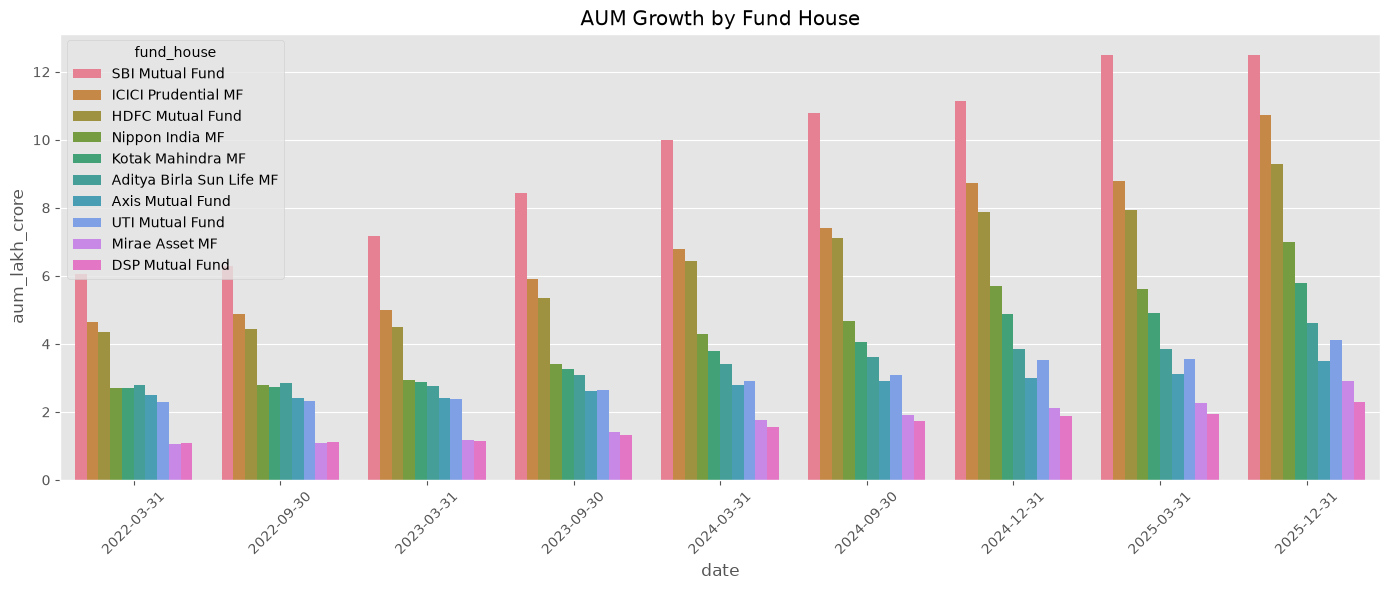

In [8]:
plt.figure(figsize=(14,6))

sns.barplot(
    data=aum,
    x="date",
    y="aum_lakh_crore",
    hue="fund_house"
)

plt.xticks(rotation=45)

plt.title("AUM Growth by Fund House")

plt.tight_layout()

plt.savefig("../reports/aum_growth.png")

plt.show()

### Insight 2

SBI Mutual Fund consistently maintained one of the highest Assets Under Management throughout the observation period, demonstrating its dominant market position.

# 3. SIP Inflow Trend

In [10]:
import kaleido

sip["month"] = pd.to_datetime(sip["month"])

fig = px.line(
    sip,
    x="month",
    y="sip_inflow_crore",
    title="Monthly SIP Inflow"
)

peak = sip.loc[
    sip["sip_inflow_crore"].idxmax()
]

fig.add_annotation(
    x=peak["month"],
    y=peak["sip_inflow_crore"],
    text="All-Time High",
    showarrow=True
)

fig.show()

try:
    fig.write_image("../reports/sip_trend.png")
except ImportError:
    fig.write_html("../reports/sip_trend.html")
    print("Kaleido not installed. Saved interactive plot at ../reports/sip_trend.html")
except Exception as e:
    fig.write_html("../reports/sip_trend.html")
    print(f"Could not write static image ({e}). Saved interactive plot at ../reports/sip_trend.html")

Could not write static image (
Image export using the "kaleido" engine requires the Kaleido package,
which can be installed using pip:

    $ pip install --upgrade kaleido
). Saved interactive plot at ../reports/sip_trend.html


# 3. SIP Inflow Trend

In [12]:
import kaleido

sip["month"] = pd.to_datetime(sip["month"])

fig = px.line(
    sip,
    x="month",
    y="sip_inflow_crore",
    title="Monthly SIP Inflow"
)

peak = sip.loc[
    sip["sip_inflow_crore"].idxmax()
]

fig.add_annotation(
    x=peak["month"],
    y=peak["sip_inflow_crore"],
    text="All-Time High",
    showarrow=True
)

fig.show()

try:
    fig.write_image("../reports/sip_trend.png")
except ImportError:
    fig.write_html("../reports/sip_trend.html")
    print("Kaleido not installed. Saved interactive plot at ../reports/sip_trend.html")
except Exception as e:
    fig.write_html("../reports/sip_trend.html")
    print(f"Could not write static image ({e}). Saved interactive plot at ../reports/sip_trend.html")

Could not write static image (
Image export using the "kaleido" engine requires the Kaleido package,
which can be installed using pip:

    $ pip install --upgrade kaleido
). Saved interactive plot at ../reports/sip_trend.html


### Insight 3

Monthly SIP inflows showed consistent long-term growth, reaching their highest value at the end of the observed period.

# 4. Category Inflow Heatmap

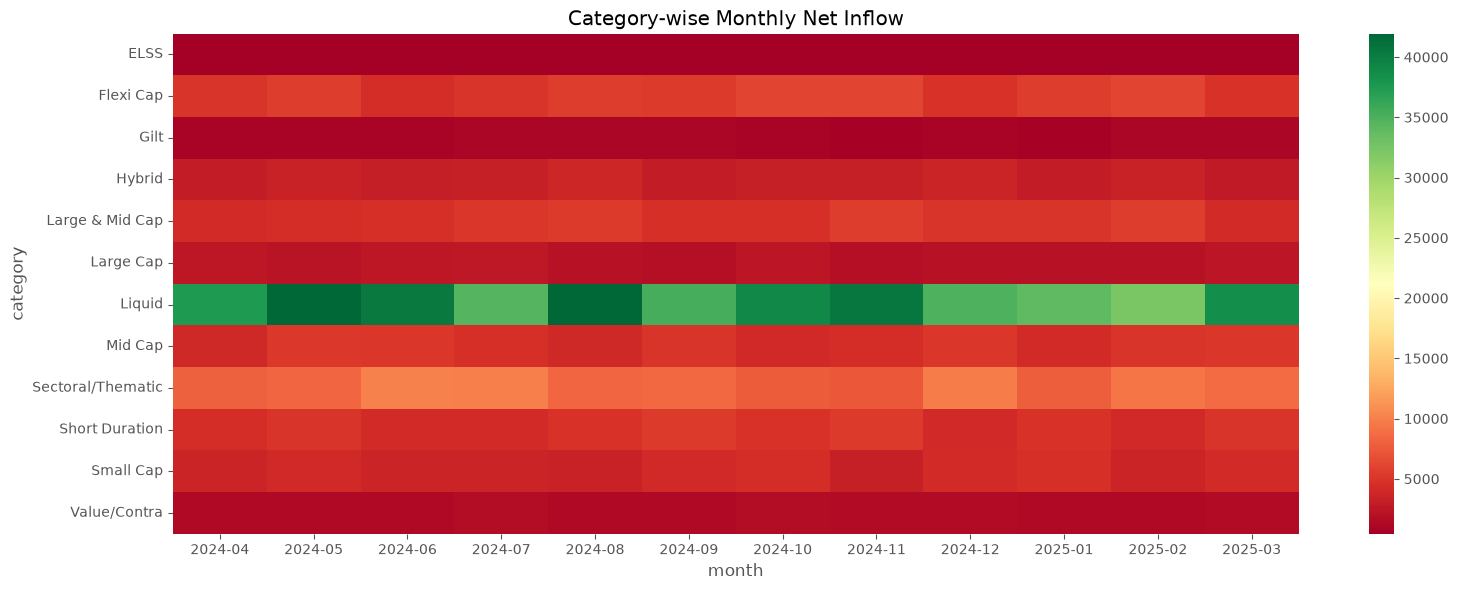

In [13]:
pivot = category.pivot(
    index="category",
    columns="month",
    values="net_inflow_crore"
)

plt.figure(figsize=(16,6))

sns.heatmap(
    pivot,
    cmap="RdYlGn",
    annot=False
)

plt.title("Category-wise Monthly Net Inflow")

plt.tight_layout()

plt.savefig("../reports/category_heatmap.png")

plt.show()

### Insight 4

Equity-oriented categories consistently attracted higher net inflows compared to debt and hybrid categories across most months.

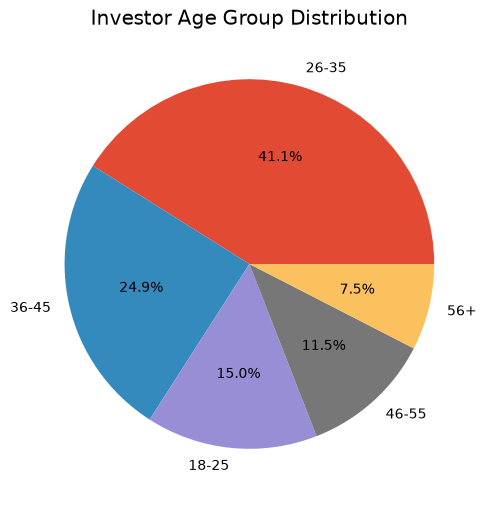

In [14]:
plt.figure(figsize=(6,6))

transactions["age_group"].value_counts().plot.pie(
    autopct="%1.1f%%"
)

plt.ylabel("")

plt.title("Investor Age Group Distribution")

plt.savefig("../reports/age_distribution.png")

plt.show()

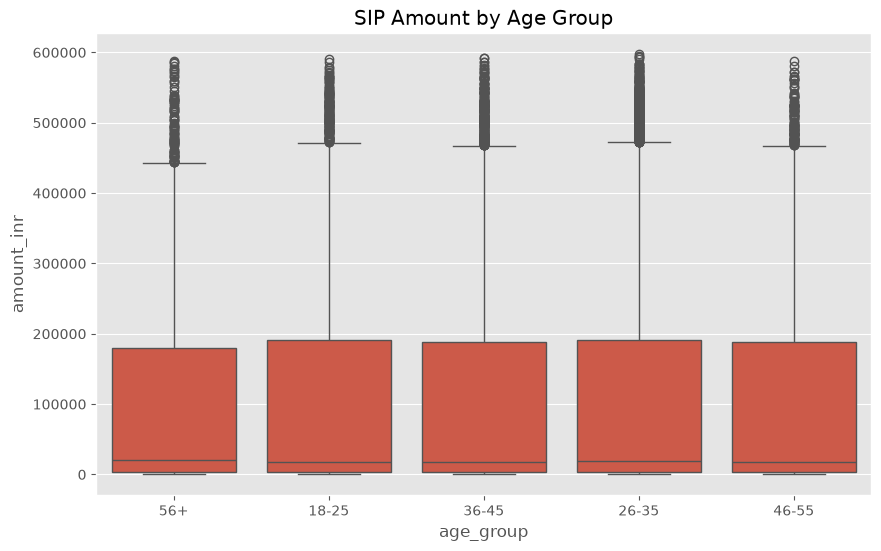

In [15]:
plt.figure(figsize=(10,6))

sns.boxplot(
    data=transactions,
    x="age_group",
    y="amount_inr"
)

plt.title("SIP Amount by Age Group")

plt.savefig("../reports/age_boxplot.png")

plt.show()

### Insight 5

The majority of investments were contributed by middle-aged investors, while transaction values varied considerably across age groups.

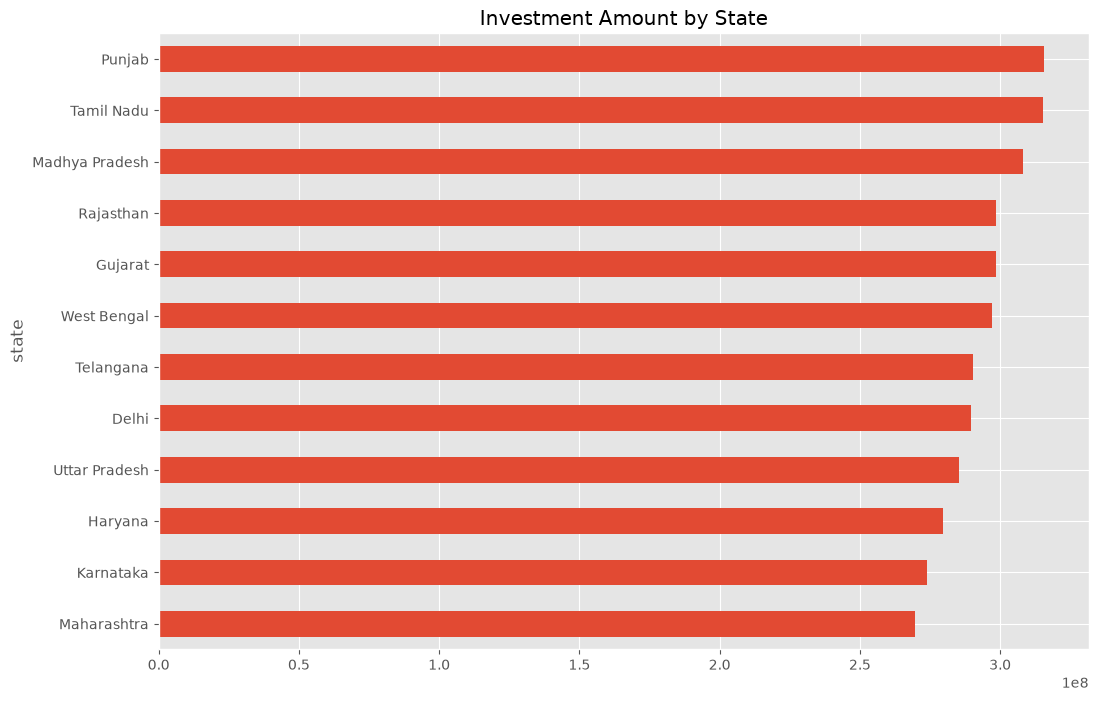

In [16]:
state = (
    transactions
    .groupby("state")["amount_inr"]
    .sum()
    .sort_values()
)

plt.figure(figsize=(12,8))

state.plot.barh()

plt.title("Investment Amount by State")

plt.savefig("../reports/state_distribution.png")

plt.show()

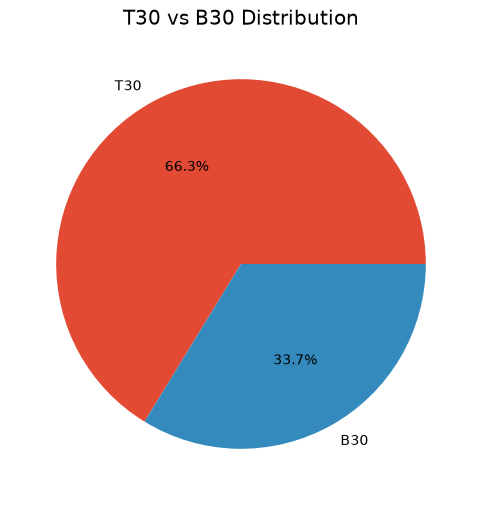

In [17]:
plt.figure(figsize=(6,6))

transactions["city_tier"].value_counts().plot.pie(
    autopct="%1.1f%%"
)

plt.ylabel("")

plt.title("T30 vs B30 Distribution")

plt.savefig("../reports/city_tier.png")

plt.show()

### Insight 6

Metro (T30) cities contributed a larger share of investments compared to B30 cities.

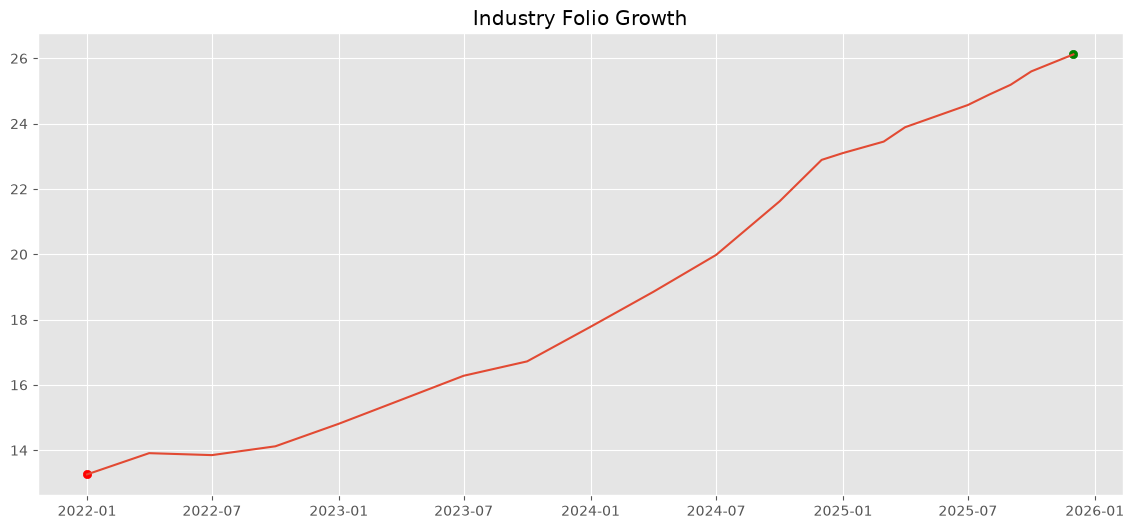

In [18]:
folio["month"] = pd.to_datetime(
    folio["month"]
)

plt.figure(figsize=(14,6))

plt.plot(
    folio["month"],
    folio["total_folios_crore"]
)

plt.scatter(
    folio.iloc[0]["month"],
    folio.iloc[0]["total_folios_crore"],
    color="red"
)

plt.scatter(
    folio.iloc[-1]["month"],
    folio.iloc[-1]["total_folios_crore"],
    color="green"
)

plt.title("Industry Folio Growth")

plt.savefig("../reports/folio_growth.png")

plt.show()

# 8. NAV Return Correlation Matrix

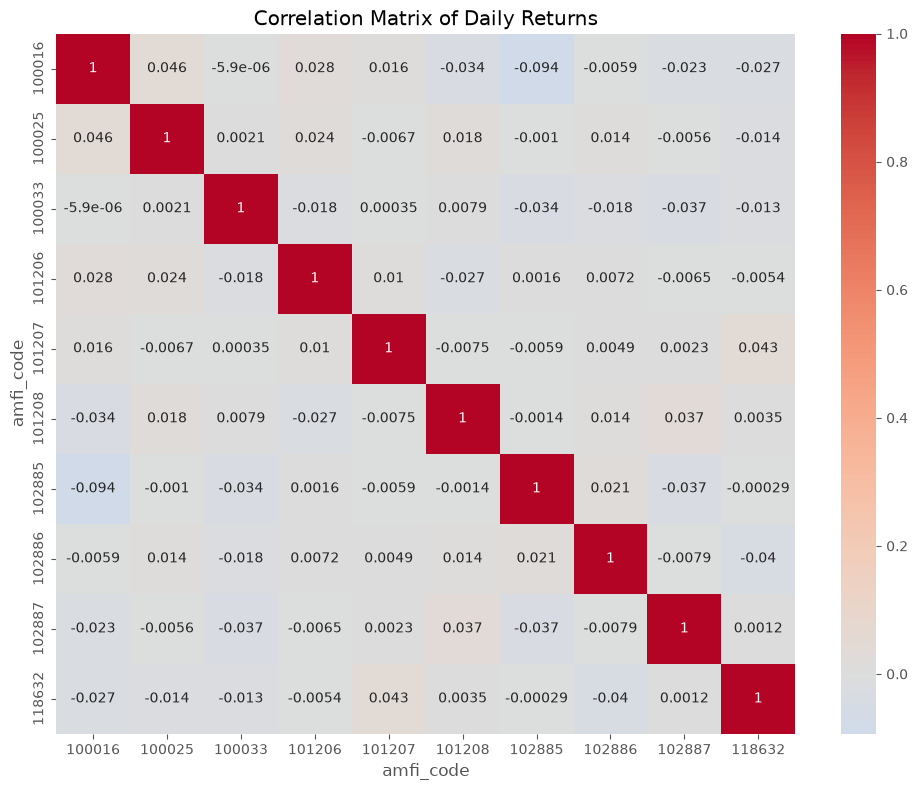

In [19]:
# Select first 10 funds
selected = nav["amfi_code"].unique()[:10]

corr_df = nav[
    nav["amfi_code"].isin(selected)
].copy()

# Daily return
corr_df["daily_return"] = (
    corr_df
    .groupby("amfi_code")["nav"]
    .pct_change()
)

pivot = corr_df.pivot(
    index="date",
    columns="amfi_code",
    values="daily_return"
)

plt.figure(figsize=(10,8))

sns.heatmap(
    pivot.corr(),
    annot=True,
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Matrix of Daily Returns")

plt.tight_layout()

plt.savefig("../reports/nav_correlation.png")

plt.show()

### Insight 8

Large-cap funds exhibited stronger positive correlations, indicating similar movement patterns under common market conditions.

# 9. Sector Allocation Analysis

In [21]:
import os
import kaleido

sector = (
    portfolio
    .groupby("sector")["weight_pct"]
    .sum()
)

fig = px.pie(
    names=sector.index,
    values=sector.values,
    hole=0.5,
    title="Sector Allocation Across Equity Funds"
)

fig.show()

def save_plotly(fig, filename, output_dir="../reports"):

    os.makedirs(output_dir, exist_ok=True)
    png_path = os.path.join(output_dir, f"{filename}.png")
    html_path = os.path.join(output_dir, f"{filename}.html")

    try:
        fig.write_image(png_path)
        print(f"Saved static image at {png_path}")
    except ImportError:
        fig.write_html(html_path)
        print("Kaleido not installed. Saved interactive plot at", html_path)
    except Exception as e:
        fig.write_html(html_path)
        print(f"Could not write static image ({e}). Saved interactive plot at {html_path}")

save_plotly(fig, "sector_allocation")

Could not write static image (
Image export using the "kaleido" engine requires the Kaleido package,
which can be installed using pip:

    $ pip install --upgrade kaleido
). Saved interactive plot at ../reports\sector_allocation.html


### Insight 9

Financial services, Information Technology, and Energy sectors represented the largest portfolio allocations across equity funds.

# 10. Key Findings

1. Mutual fund NAVs generally followed a long-term upward trend between 2022 and 2026.

2. SBI Mutual Fund consistently maintained the largest Assets Under Management.

3. Monthly SIP inflows reached record highs toward the end of 2025.

4. Equity-oriented categories attracted the highest net inflows.

5. Investor participation was strongest among middle-aged investors.

6. T30 cities generated a higher investment volume than B30 cities.

7. Industry folio counts nearly doubled over the observed period.

8. Large-cap funds demonstrated stronger return correlations.

9. Financial Services remained the largest portfolio allocation sector.

10. Overall industry indicators reflected sustained growth in mutual fund investments across the study period.